# Loan Predict Project
### Using machine learning techniques to predict loan payments.

In [13]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [14]:
#import Lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
#data
tra_df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Project/Data/train.csv')

In [16]:
tra_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [17]:
tra_df.set_index(tra_df.Loan_ID, inplace = True)

In [18]:
#Sử dụng 'Loan_ID' làm index cho data frame và loại bỏ 'Loan_ID' còn lại trong bảng
tra_df.drop('Loan_ID', axis=1, inplace=True)

In [19]:
tra_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [20]:
tra_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, LP001002 to LP002990
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 62.4+ KB


In [21]:
features = ['Gender','Married','Dependents','Education','Self_Employed','Credit_History','Property_Area']
def conve_ca(df,features):
    for i in features:
        df[i] = df[i].astype('category')
conve_ca(tra_df,features)

In [22]:
tra_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, LP001002 to LP002990
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Gender             601 non-null    category
 1   Married            611 non-null    category
 2   Dependents         599 non-null    category
 3   Education          614 non-null    category
 4   Self_Employed      582 non-null    category
 5   ApplicantIncome    614 non-null    int64   
 6   CoapplicantIncome  614 non-null    float64 
 7   LoanAmount         592 non-null    float64 
 8   Loan_Amount_Term   600 non-null    float64 
 9   Credit_History     564 non-null    category
 10  Property_Area      614 non-null    category
 11  Loan_Status        614 non-null    object  
dtypes: category(7), float64(3), int64(1), object(1)
memory usage: 33.9+ KB


In [23]:
tra_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,614.000000,614.000000,592.000000,600.00000
mean,5403.459283,1621.245798,146.412162,342.00000
std,6109.041673,2926.248369,85.587325,65.12041
min,150.000000,0.000000,9.000000,12.00000
25%,2877.500000,0.000000,100.000000,360.00000
50%,3812.500000,1188.500000,128.000000,360.00000
75%,5795.000000,2297.250000,168.000000,360.00000
max,81000.000000,41667.000000,700.000000,480.00000


In [24]:
tra_df.describe(include='category')

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area
count,601,611,599,614,582,564.0,614
unique,2,2,4,2,2,2.0,3
top,Male,Yes,0,Graduate,No,1.0,Semiurban
freq,489,398,345,480,500,475.0,233


## EDA
### Target Variable: Loan_Status


In [25]:
tra_df['Loan_Status'].value_counts(normalize=True)

,proportion
Loan_Status,
Y,0.687296
N,0.312704


Gần 69% các khoản vay sẽ được chấp nhận

In [26]:
tra_df['Gender'].value_counts(normalize=True)

,proportion
Gender,
Male,0.813644
Female,0.186356


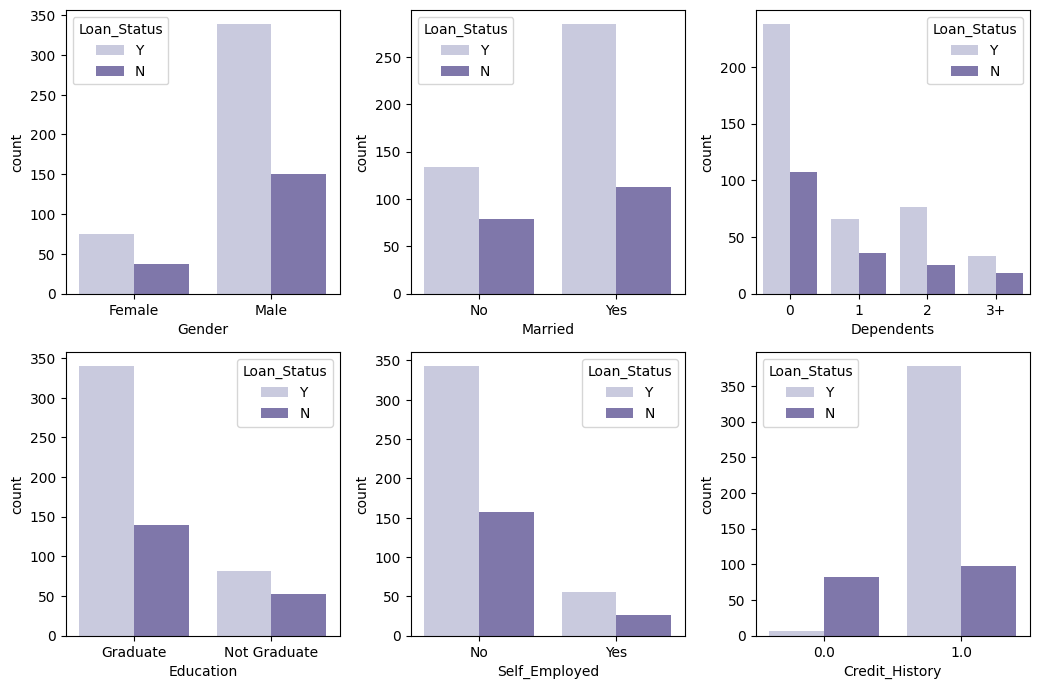

In [27]:
cols = ['Gender','Married','Dependents','Education','Self_Employed','Credit_History']

n_rows = 2
n_cols = 3
fix, ax = plt.subplots(n_rows,n_cols,figsize=(n_cols*3.5,n_rows*3.5))

for r in range (0,n_rows):
    for c in range (0,n_cols):
        i = r*n_cols + c
        if i < len(cols):
            ax_i = ax[r,c]
            sns.countplot(data=tra_df,x = cols[i], hue = 'Loan_Status', ax=ax_i, palette= 'Purples')
plt.tight_layout()

* Fig1: Người vay là nam giới nhiều hơn hẳn nữ giới
* Fig2: Tỷ lệ chấp nhận vay của người đã kết hôn cao hơn người chưa kết hôn
* Fig3: Người chưa có con cái có nhu cầu đi vay nhiều nhất
* Fig4: Những người đã tốt nghiệp có xu hương vay nhiều hơn
* Fig5: Những người làm thuê vay nhiều hơn
* Fig6: Những người có lịch sử tín dụng xấu không được chấp nhận khoản vay

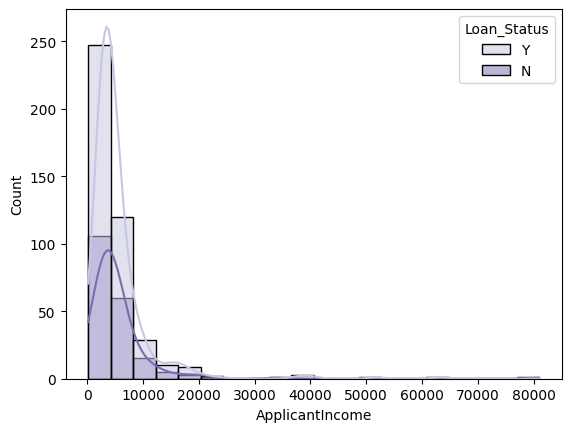

In [28]:
sns.histplot(data=tra_df,x='ApplicantIncome',hue='Loan_Status',bins=20,kde=True, palette= 'Purples');

Nhóm thu nhập từ 0 đến 10000 có số người vay nhiều nhất

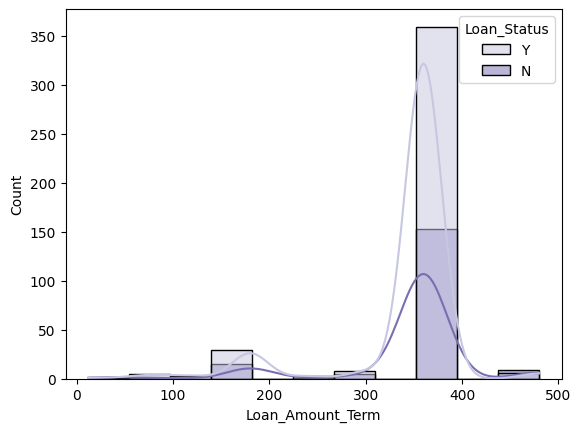

In [29]:
sns.histplot(data=tra_df,x='Loan_Amount_Term',hue='Loan_Status',kde=True, palette= 'Purples');

Phần lớn các khoản vay trong 360 tháng

/tmp/ipykernel_507/156093091.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=tra_df[col], palette='Purples')
/tmp/ipykernel_507/156093091.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=tra_df[col], palette='Purples')
/tmp/ipykernel_507/156093091.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=tra_df[col], palette='Purples')


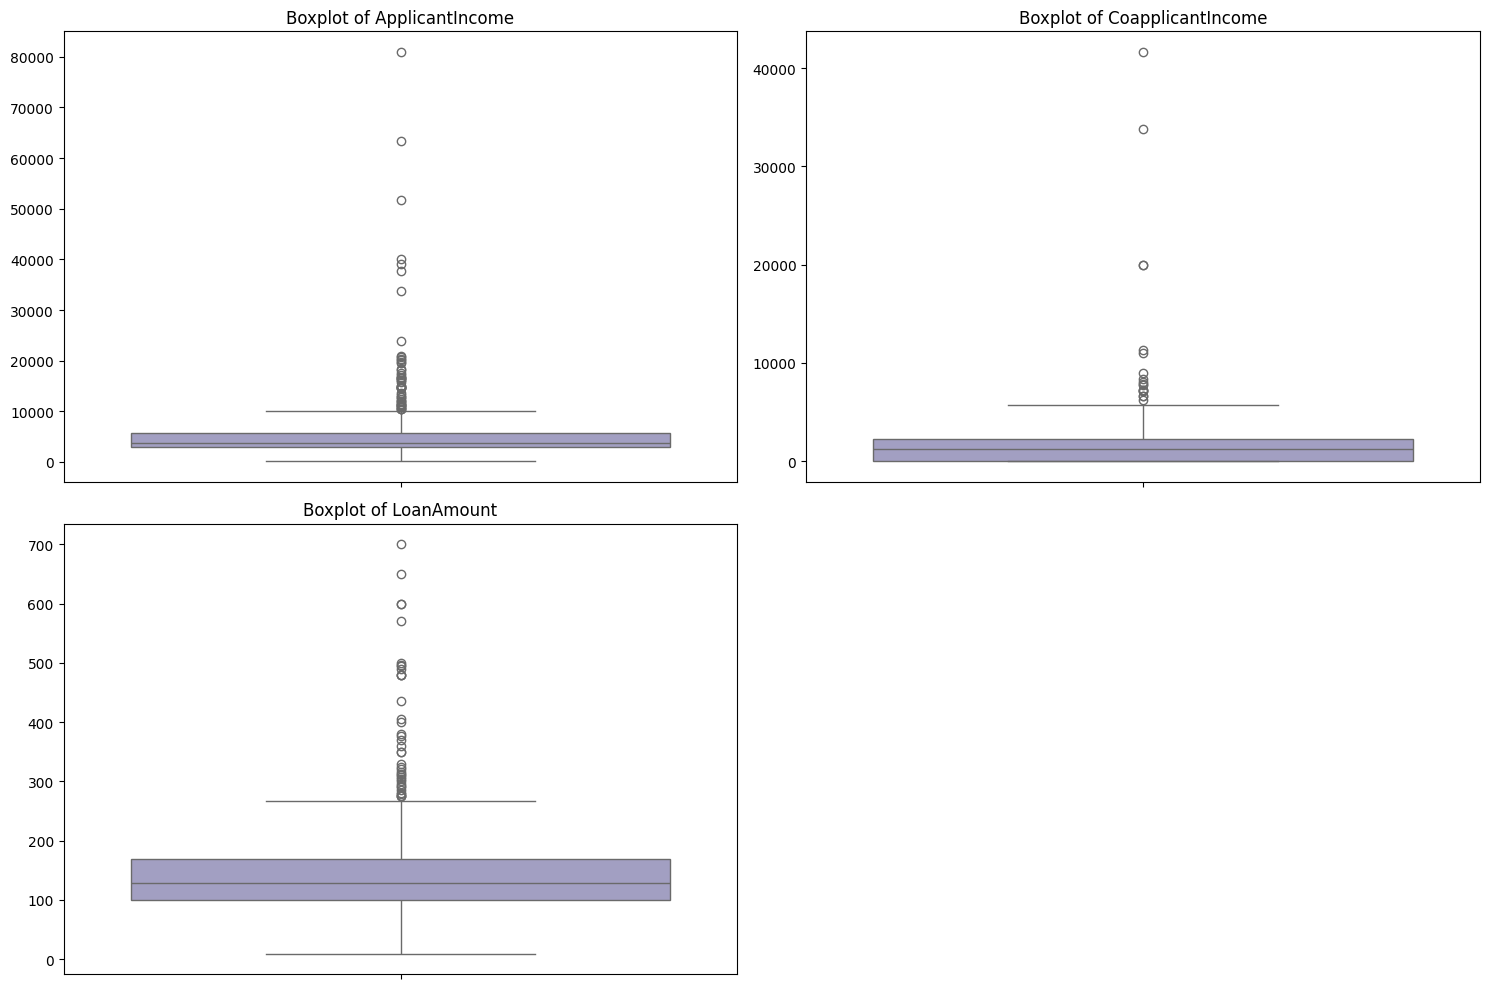

In [30]:
#Boxplot
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=tra_df[col], palette='Purples')
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

ApplicantIncome: Có 50 outliers. Ngưỡng trên của bạn là 10.171,25. Điều này có nghĩa là bất kỳ ai có thu nhập trên mức này đều được coi là người thu nhập cực cao so với mặt bằng chung của tập dữ liệu.

LoanAmount: Có 39 outliers. Ngưỡng trên là 270,0. Những khoản vay lớn hơn 270 đang nằm ngoài phạm vi hoạt động thông thường của các khách hàng khác.

### Outlier Treatment using Winsorizing

In [31]:
for col in numerical_cols:
    # Calculate the 5th and 95th percentiles
    lower_bound_winsor = tra_df[col].quantile(0.05)
    upper_bound_winsor = tra_df[col].quantile(0.95)

    # Apply Winsorizing
    tra_df[col] = np.where(tra_df[col] < lower_bound_winsor, lower_bound_winsor,
                             np.where(tra_df[col] > upper_bound_winsor, upper_bound_winsor, tra_df[col]))

    print(f"Winsorizing applied to '{col}'. New min: {tra_df[col].min():.2f}, New max: {tra_df[col].max():.2f}")

Winsorizing applied to 'ApplicantIncome'. New min: 1897.55, New max: 14583.00
Winsorizing applied to 'CoapplicantIncome'. New min: 0.00, New max: 4997.40
Winsorizing applied to 'LoanAmount'. New min: 56.00, New max: 297.80


In [32]:
display(tra_df[numerical_cols].describe())

,ApplicantIncome,CoapplicantIncome,LoanAmount
count,614.000000,614.000000,592.000000
mean,4914.303013,1389.080326,140.611486
std,3173.154644,1548.446489,60.805004
min,1897.550000,0.000000,56.000000
25%,2877.500000,0.000000,100.000000
50%,3812.500000,1188.500000,128.000000
75%,5795.000000,2297.250000,168.000000
max,14583.000000,4997.400000,297.800000
